In [1]:
!pip install ultralytics

Определение детектора, совместимого с YOLO

In [2]:
from pathlib import Path
from typing import Any, Dict, Optional, Union

import numpy as np
from ultralytics import YOLO

from manuscript.data import Block, Line, Page, Word
from manuscript.utils import organize_page, read_image


class YoloDetector:
    def __init__(
        self,
        weights: Union[str, Path],
        conf: float = 0.25,
        iou: float = 0.7,
        imgsz: int = 640,
        device: Optional[str] = None,
    ):
        self.conf, self.iou, self.imgsz = conf, iou, imgsz
        self.model = YOLO(str(weights))
        if device:
            self.model.to(device)

    def predict(
        self,
        img_or_path: Union[str, Path, np.ndarray],
        sort_reading_order: bool = True,
        split_into_columns: bool = True,
        max_columns: int = 10,
        *args,
        **kwargs
    ) -> Dict[str, Any]:

        result = self.model.predict(
            read_image(img_or_path),
            conf=self.conf,
            iou=self.iou,
            imgsz=self.imgsz,
            verbose=False,
        )[0]

        words = [
            Word(
                polygon=[(x1, y1), (x2, y1), (x2, y2), (x1, y2)],
                detection_confidence=conf,
            )
            for x1, y1, x2, y2, conf, _ in
            (result.boxes.data.tolist() if result.boxes else [])
        ]

        page = Page(
            blocks=[Block(lines=[Line(words=words, order=0)], order=0)]
        )

        if sort_reading_order and words:
            page = organize_page(
                page,
                max_splits=max_columns,
                use_columns=split_into_columns,
            )
        else:
            for i, w in enumerate(words):
                w.order = i

        return {"page": page, "raw_results": result}

c:\Users\pasha\manuscript-ocr\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[TRBA] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
[CharLM] Device configuration:
  Requested device: cuda
  Requested providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Active providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
  Running on: CUDAExecutionProvider
{'page': Page(blocks=[Block(lines=[Line(words=[Word(polygon=[(317.00347900390625, 464.96246337890625), (410.5071105957031, 464.96246337890625), (410.5071105957031, 537.2694702148438), (317.00347900390625, 537.2694702148438)], detection_confidence=0.6581078171730042, text='з.)', recognition_confidence=0.9681670069694519, order=0)], order=0)], words=[], order=0), Block(lines=[Line(words=[Word(polygon=[(442.2320556640625, 435.7010192871094), (690.6074829101562, 435.7010192871094), (690.6074829101562, 535.0379028320312), (442.2320

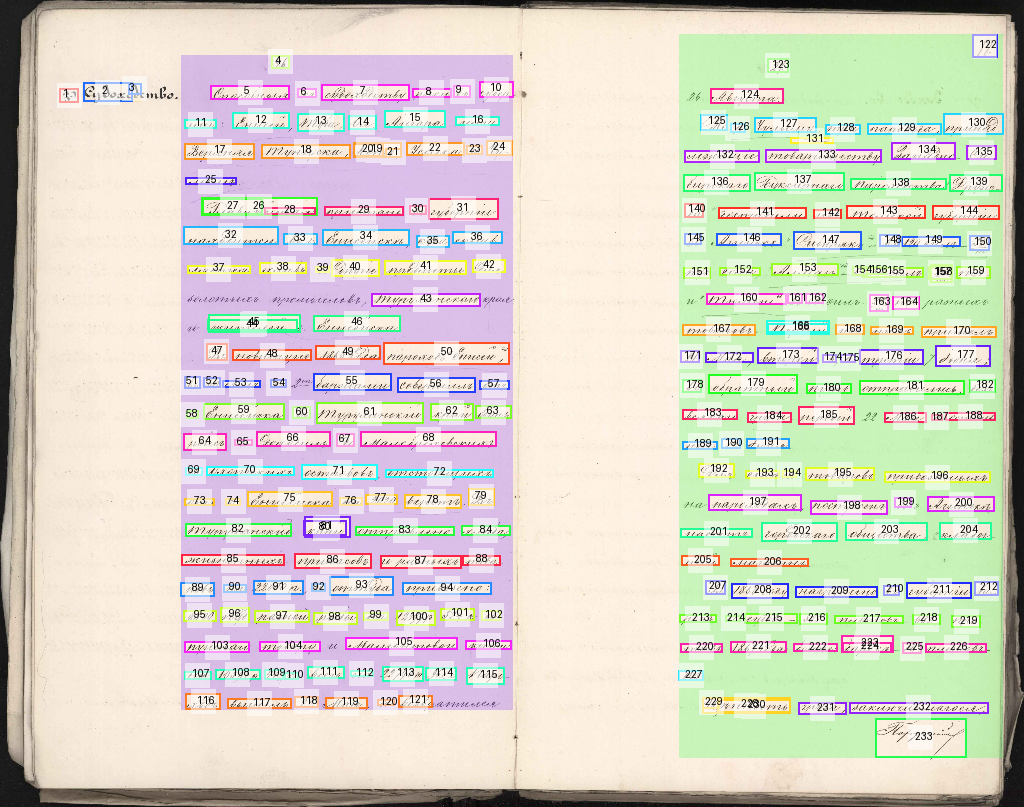

In [3]:
from huggingface_hub import hf_hub_download

from manuscript import Pipeline
from manuscript.utils.visualization import visualize_page
from manuscript.recognizers import TRBA
from manuscript.correctors import CharLM


model_path = hf_hub_download(repo_id="Daniil-Domino/yolo11x-text-detection", filename="model.pt")
image_path = "C:\\Users\\pasha\\manuscript-ocr\\example\\ocr_example_image.jpg"

pipeline = Pipeline(
    detector=YoloDetector(
        weights=model_path,
        conf=0.25,
    ), # Детектор Daniil-Domino/yolo11x-text-detection, совместимый с manuscript благодаря классу-обёртке YoloDetector
    recognizer=TRBA(weights="trba_lite_g1"),
    corrector=CharLM(weights="modern_charlm_g1"),
)

# Запуск пайплайна
result = pipeline.predict(image_path)

# Весь объект результата
print(result)

# Текст
text = pipeline.get_text(result["page"])
print(text)

# Визуализация
visualize_page(image_path, result["page"], show_lines=False, show_numbers=True, max_size = 1024)